# **Motivation**

In protein–ligand binding affinity prediction tasks, data leakage is a critical issue that can lead to overly optimistic model performance and poor generalization to unseen data. Leakage can arise from multiple sources, including duplicated entries, repeated ligands or proteins across splits, highly similar chemical structures, and shared experimental conditions (assays).

This notebook aims to systematically identify and quantify potential leakage sources in both the pChEMBL and pKi datasets. Specifically, we investigate:

- Exact duplicate entries (same protein–ligand pairs)
- Ligand leakage through repeated or highly similar molecules
- Protein leakage via repeated or similar protein sequences
- Assay-level leakage due to shared experimental conditions
- Cross leakage between ligand–protein pairs

By understanding these sources, we can design more robust data splitting strategies (e.g., scaffold split, protein split) and ensure that downstream machine learning models provide realistic and reliable performance estimates.

## **Set Up**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_style("whitegrid")

#Load data
df_pchembl = pd.read_csv("data/processed/features_processed_pchembl.csv") 
df_pki = pd.read_csv("data/processed/features_processed_pki.csv")

## **Duplicate Analysis**

### **pChEMBL**

In [2]:
dup_cols = ['UniProt_ID', 'CANONICAL_SMILES']

duplicates = df_pchembl.duplicated(subset=dup_cols)
print(f"Exact duplicates pChEMBL: {duplicates.sum()}")

df_pchembl[duplicates].head()

Exact duplicates pChEMBL: 6217


,PDB ID,Chain ID,UniProt_ID,PDB_Start,PDB_End,UniProt_Start,UniProt_End,LIGAND_ID,LIGAND_TYPE,POSITIONS,...,ESM2_1271,ESM2_1272,ESM2_1273,ESM2_1274,ESM2_1275,ESM2_1276,ESM2_1277,ESM2_1278,ESM2_1279,ESM2_1280
4,4bb2,B,P08185,350.0,383.0,372.0,405.0,STR,non-polymer,351-352-353-354-355-356-357-358-359-360-361-36...,...,0.066247,0.058355,-0.145837,0.200997,0.009985,-0.002678,0.114186,-0.021531,-0.067303,-0.111025
6,7rec,G,Q9UQM7,345.0,475.0,345.0,475.0,7ZV,non-polymer,343-344-345-346-347-348-349-350-351-352-353-35...,...,0.101454,-0.021750,-0.060294,0.036680,-0.051975,0.016886,0.059456,-0.110190,-0.061812,0.114878
7,7rec,A,Q9UQM7,345.0,475.0,345.0,475.0,7ZV,non-polymer,343-344-345-346-347-348-349-350-351-352-353-35...,...,0.085874,-0.027529,-0.058364,0.048734,-0.056190,0.008315,0.082552,-0.130166,-0.068717,0.128761
8,7rec,E,Q9UQM7,345.0,475.0,345.0,475.0,7ZV,non-polymer,344-345-346-347-348-349-350-351-352-353-354-35...,...,0.090586,-0.032426,-0.057774,0.035048,-0.055633,0.014945,0.062508,-0.106177,-0.069099,0.121284
9,7rec,D,Q9UQM7,345.0,475.0,345.0,475.0,7ZV,non-polymer,342-343-344-345-346-347-348-349-350-351-352-35...,...,0.100603,-0.021202,-0.064148,0.038046,-0.056781,0.015748,0.051342,-0.112479,-0.061424,0.114461


### **pKi**

In [3]:
dup_cols = ['UniProt_ID', 'CANONICAL_SMILES']

duplicates = df_pki.duplicated(subset=dup_cols)
print(f"Exact duplicates pKi: {duplicates.sum()}")

df_pki[duplicates].head()

Exact duplicates pKi: 1801


,PDB ID,Chain ID,UniProt_ID,PDB_Start,PDB_End,UniProt_Start,UniProt_End,LIGAND_ID,LIGAND_TYPE,POSITIONS,...,ESM2_1271,ESM2_1272,ESM2_1273,ESM2_1274,ESM2_1275,ESM2_1276,ESM2_1277,ESM2_1278,ESM2_1279,ESM2_1280
3,1ogu,A,P24941,1.0,298.0,1.0,298.0,ST8,non-polymer,-2--1-0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16...,...,0.018536,-0.004901,-0.090479,0.069037,0.034864,0.012300,0.047755,-0.135179,0.091673,0.027348
5,2pdi,A,P15121,0.0,315.0,1.0,316.0,ZST,non-polymer,1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-1...,...,-0.013149,0.020320,-0.066263,-0.024348,-0.029203,-0.031345,0.105126,-0.171235,0.068171,0.029271
6,2pdm,A,P15121,0.0,315.0,1.0,316.0,ZST,non-polymer,1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-1...,...,-0.016499,0.021003,-0.068391,-0.022485,-0.026378,-0.029602,0.109963,-0.168314,0.070815,0.027565
7,2pdx,A,P15121,0.0,315.0,1.0,316.0,ZST,non-polymer,1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-1...,...,-0.019869,0.019748,-0.062732,-0.023501,-0.025219,-0.027943,0.113369,-0.171182,0.070037,0.018936
8,2fz8,A,P15121,0.0,315.0,1.0,316.0,ZST,non-polymer,1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-1...,...,-0.014923,0.023005,-0.067878,-0.023054,-0.027863,-0.030688,0.107849,-0.169329,0.069615,0.025570


## **Ligand Leakage**

### **pChEMBL**

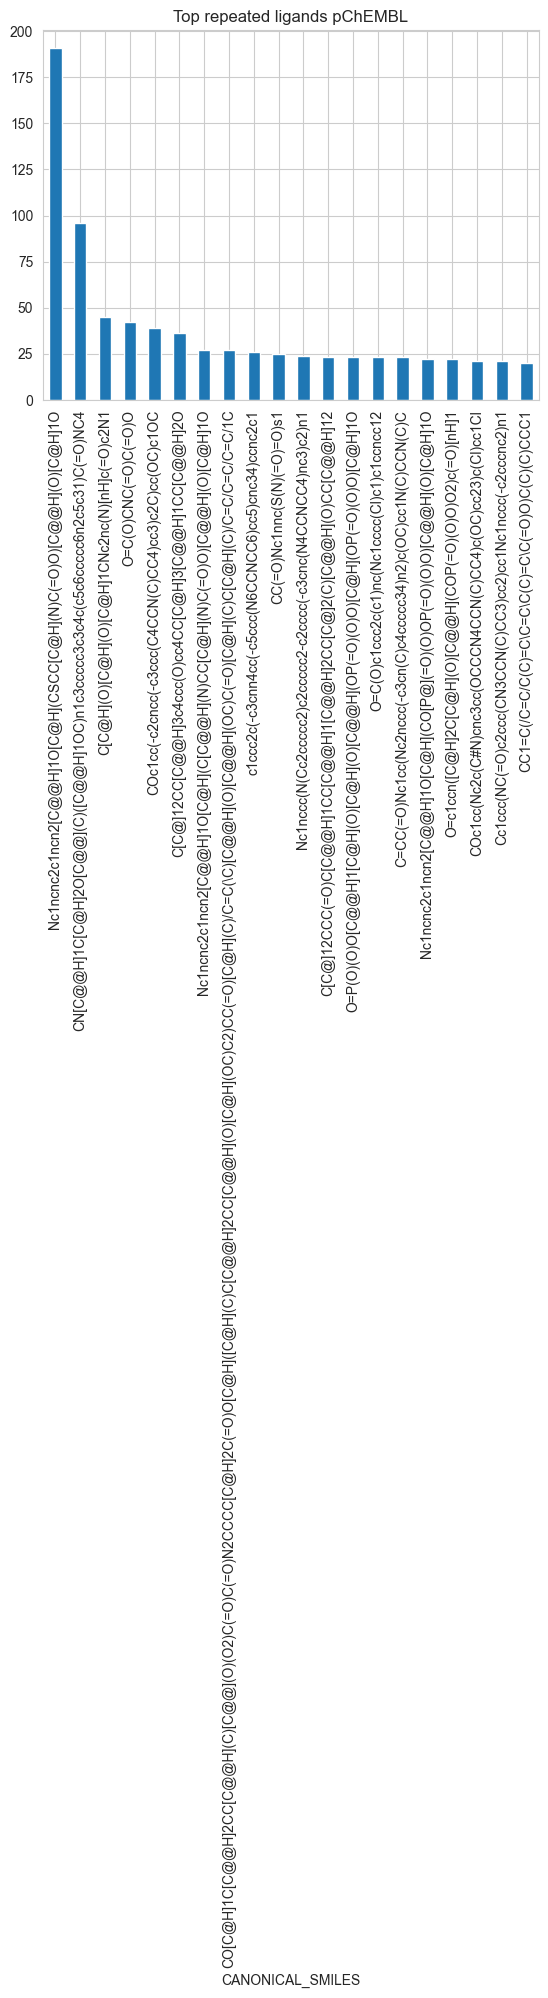

Highly similar ligand pairs pChEMBL (>0.95): 964000


In [4]:
# Same molecule different rows
ligand_counts = df_pchembl['CANONICAL_SMILES'].value_counts()

plt.figure()
ligand_counts.head(20).plot(kind='bar')
plt.title("Top repeated ligands pChEMBL")
plt.show()

# Chemical Similarity Leakage
chem_features = ['MolWt', 'MolLogP', 'TPSA']

sample = df_pchembl[chem_features].dropna().sample(1000, random_state=42)

sim_matrix = cosine_similarity(sample)

# Remove diagonal
np.fill_diagonal(sim_matrix, 0)

high_sim = (sim_matrix > 0.95).sum()
print(f"Highly similar ligand pairs pChEMBL (>0.95): {high_sim}")

### **pKi**

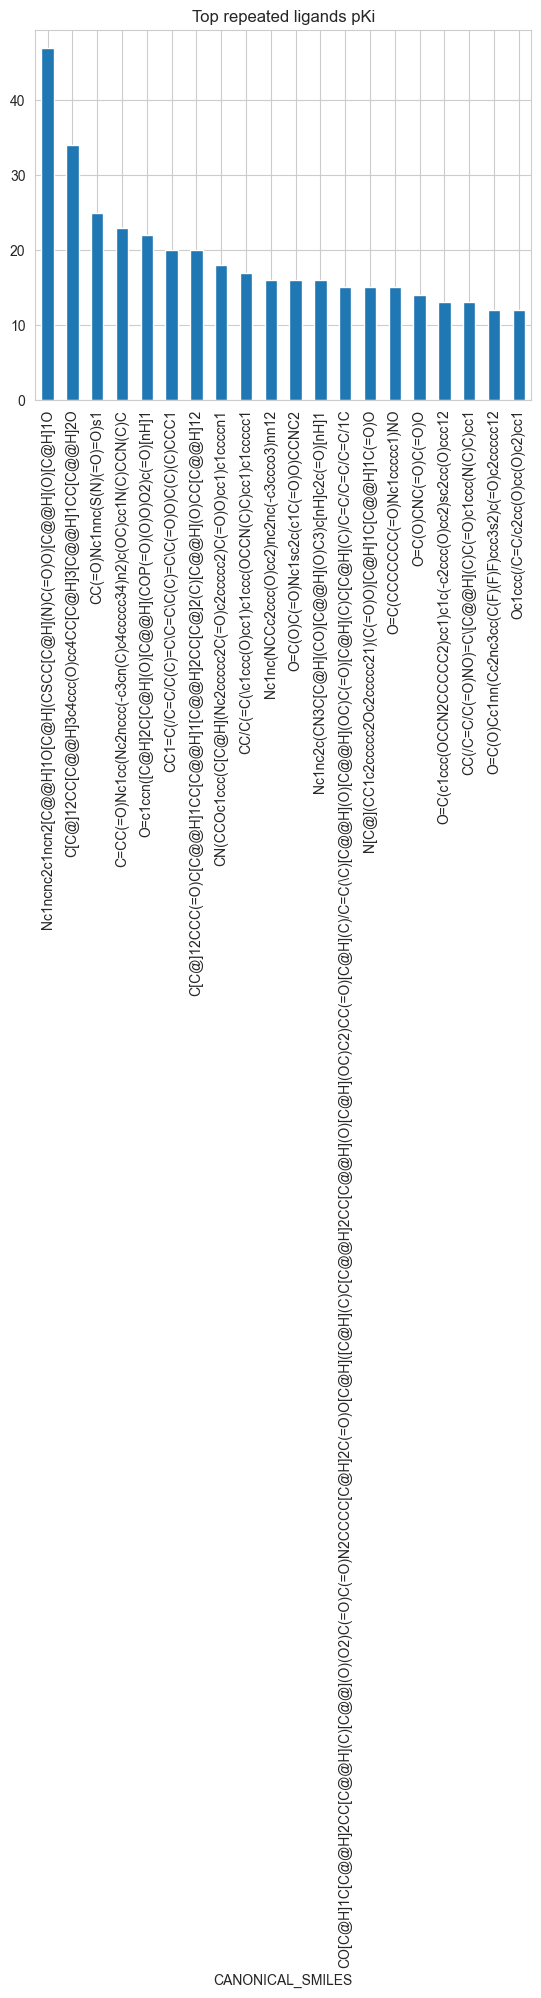

Highly similar ligand pairs pKi (>0.95): 940246


In [5]:
# Same molecule different rows
ligand_counts = df_pki['CANONICAL_SMILES'].value_counts()

plt.figure()
ligand_counts.head(20).plot(kind='bar')
plt.title("Top repeated ligands pKi")
plt.show()

# Chemical Similarity Leakage
chem_features = ['MolWt', 'MolLogP', 'TPSA']

sample = df_pki[chem_features].dropna().sample(1000, random_state=42)

sim_matrix = cosine_similarity(sample)

# Remove diagonal
np.fill_diagonal(sim_matrix, 0)

high_sim = (sim_matrix > 0.95).sum()
print(f"Highly similar ligand pairs pKi (>0.95): {high_sim}")

## **Protein Leakage** 

### **pChEMBL**

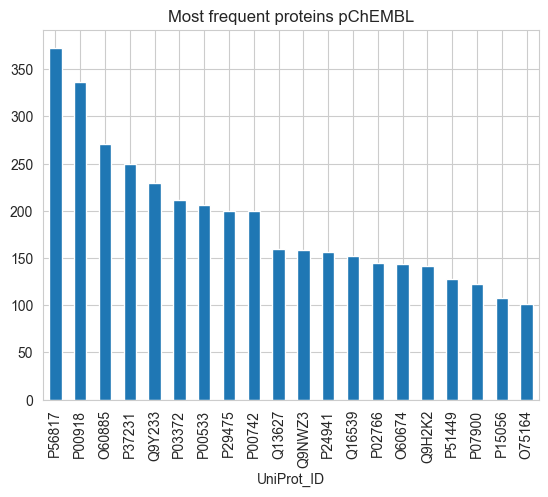

Unique proteins: 907
Highly similar proteins pChEMBL (>0.98): 11100


In [6]:
protein_counts = df_pchembl['UniProt_ID'].value_counts()

plt.figure()
protein_counts.head(20).plot(kind='bar')
plt.title("Most frequent proteins pChEMBL")
plt.show()

print("Unique proteins:", df_pchembl['UniProt_ID'].nunique())

# Embedding Similarity Leakage
esm_cols = [c for c in df_pchembl.columns if c.startswith('ESM2_')]

sample_esm = df_pchembl.dropna(subset=esm_cols).sample(1000, random_state=42)

emb = sample_esm[esm_cols].values

sim = cosine_similarity(emb)
np.fill_diagonal(sim, 0)

print("Highly similar proteins pChEMBL (>0.98):", (sim > 0.98).sum())

### **pKi**

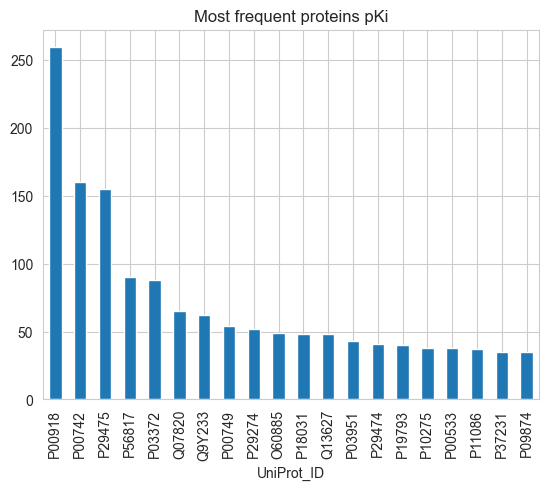

Unique proteins: 393
Highly similar proteins pKi (>0.98): 21418


In [8]:
protein_counts = df_pki['UniProt_ID'].value_counts()

plt.figure()
protein_counts.head(20).plot(kind='bar')
plt.title("Most frequent proteins pKi")
plt.show()

print("Unique proteins:", df_pki['UniProt_ID'].nunique())

# Embedding Similarity Leakage
esm_cols = [c for c in df_pki.columns if c.startswith('ESM2_')]

sample_esm = df_pki.dropna(subset=esm_cols).sample(1000, random_state=42)

emb = sample_esm[esm_cols].values

sim = cosine_similarity(emb)
np.fill_diagonal(sim, 0)

print("Highly similar proteins pKi (>0.98):", (sim > 0.98).sum())

## **Assay Leakage**

### **pChEMBL**

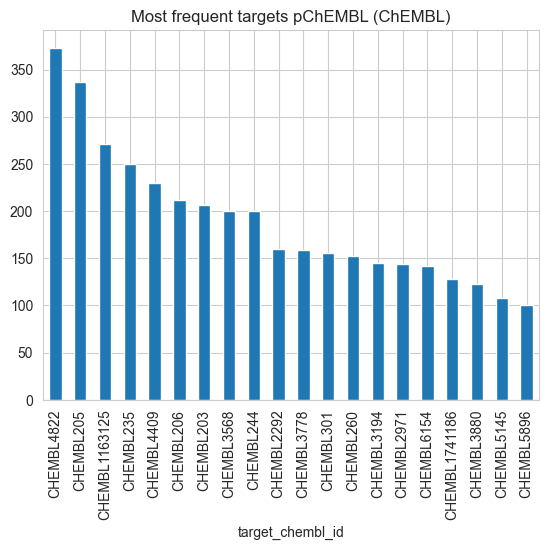

,mean,std,count
target_chembl_id,,,
CHEMBL4822,6.945979,1.416640,373
CHEMBL205,7.350297,1.273708,337
CHEMBL1163125,6.548487,1.194425,271
CHEMBL235,7.091480,1.261055,250
CHEMBL4409,7.977652,1.179093,230


In [10]:
assay_counts = df_pchembl['target_chembl_id'].value_counts()

plt.figure()
assay_counts.head(20).plot(kind='bar')
plt.title("Most frequent targets pChEMBL (ChEMBL)")
plt.show()

# Check variance within same assay
grouped = df_pchembl.groupby('target_chembl_id')['pchembl_value'].agg(['mean', 'std', 'count'])

display(grouped.sort_values('count', ascending=False).head())

### **pKi**

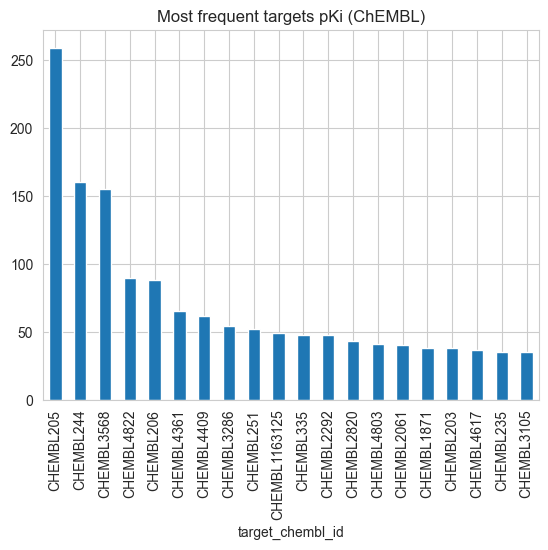

,mean,std,count
target_chembl_id,,,
CHEMBL205,7.226571,1.380157,259
CHEMBL244,8.379076,0.989249,160
CHEMBL3568,7.052811,0.493599,155
CHEMBL4822,7.719189,1.045312,90
CHEMBL206,8.523651,0.922384,88


In [11]:
assay_counts = df_pki['target_chembl_id'].value_counts()

plt.figure()
assay_counts.head(20).plot(kind='bar')
plt.title("Most frequent targets pKi (ChEMBL)")
plt.show()

# Check variance within same assay
grouped = df_pki.groupby('target_chembl_id')['pKi'].agg(['mean', 'std', 'count'])

display(grouped.sort_values('count', ascending=False).head())

## **Cross Leakage**

### **pChEMBL**

In [12]:
pair_counts = df_pchembl.groupby(['UniProt_ID', 'CANONICAL_SMILES']).size()

repeated_pairs = pair_counts[pair_counts > 1]

print(f"Repeated ligand-protein pairs pChEMBL: {len(repeated_pairs)}")

Repeated ligand-protein pairs pChEMBL: 3267


### **pKi**

In [13]:
pair_counts = df_pki.groupby(['UniProt_ID', 'CANONICAL_SMILES']).size()

repeated_pairs = pair_counts[pair_counts > 1]

print(f"Repeated ligand-protein pairs pKi: {len(repeated_pairs)}")

Repeated ligand-protein pairs pKi: 882


## **Scafold Leakage**

In [16]:
def get_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    except:
        return None

df_pchembl['scaffold'] = df_pchembl['CANONICAL_SMILES'].apply(get_scaffold)
df_pki['scaffold'] = df_pki['CANONICAL_SMILES'].apply(get_scaffold)

# Count repeated scaffolds
scaffold_counts_pchembl = df_pchembl['scaffold'].value_counts()
scaffold_counts_pki = df_pki['scaffold'].value_counts()

print("Repeated scaffolds pChEMBL:", (scaffold_counts_pchembl > 1).sum())
print("Repeated scaffolds pKi:", (scaffold_counts_pki > 1).sum())

Repeated scaffolds pChEMBL: 2737
Repeated scaffolds pKi: 699


## **Train-Test Leakage Simulation**

In [17]:
def leakage_check(df, name):
    train, test = train_test_split(df, test_size=0.2, random_state=42)

    # Ligand overlap
    lig_overlap = set(train['CANONICAL_SMILES']) & set(test['CANONICAL_SMILES'])

    # Protein overlap
    prot_overlap = set(train['UniProt_ID']) & set(test['UniProt_ID'])

    # Pair overlap
    train_pairs = set(zip(train['UniProt_ID'], train['CANONICAL_SMILES']))
    test_pairs = set(zip(test['UniProt_ID'], test['CANONICAL_SMILES']))
    pair_overlap = train_pairs & test_pairs

    print(f"\n{name} Leakage Simulation:")
    print(f"Ligand overlap: {len(lig_overlap)}")
    print(f"Protein overlap: {len(prot_overlap)}")
    print(f"Pair overlap: {len(pair_overlap)}")

leakage_check(df_pchembl, "pChEMBL")
leakage_check(df_pki, "pKi")


pChEMBL Leakage Simulation:
Ligand overlap: 1370
Protein overlap: 549
Pair overlap: 1365

pKi Leakage Simulation:
Ligand overlap: 375
Protein overlap: 204
Pair overlap: 380


# **Conclusion**

This analysis systematically investigated data leakage across five dimensions in both the pChEMBL and pKi datasets, revealing substantial redundancy and contamination risk that would undermine model evaluation under a naive random split.

- **Duplicate Analysis** identified 6,217 exact duplicate (UniProt_ID, SMILES) pairs in pChEMBL and 1,801 in pKi, arising from the same protein-ligand complex being captured across multiple PDB crystal structure chains. These are structural replicates rather than independent measurements and must be removed prior to any splitting strategy.

- **Ligand Leakage analysis** showed that both datasets are chemically dense, with 964,000 and 940,246 highly similar ligand pairs in pChEMBL and pKi respectively. This reflects the well-known clustering of bioactivity data around a small number of privileged scaffolds. 

- **Scaffold-level analysis** further confirmed this: 2,737 repeated scaffolds in pChEMBL and 699 in pKi, meaning a large fraction of the chemical space shares the same Bemis-Murcko core — a random split would routinely assign structurally identical scaffolds to both train and test.

- **Protein Leakage analysis** found 907 unique proteins in pChEMBL and 393 in pKi, with 11,100 and 21,418 highly similar ESM2 embedding pairs (cosine > 0.98) respectively. pKi is proportionally more redundant, consistent with its concentration around well-characterised target families such as kinases and proteases.

- **Assay Leakage** revealed heavy target imbalance, with CHEMBL4822 (373 entries) and CHEMBL205 (259 entries) dominating pChEMBL and pKi respectively. Intra-assay standard deviations of up to 1.4 log units reflect irreducible experimental noise across labs and assay formats, setting a hard ceiling on achievable model performance.

- **Cross Leakage** identified 3,267 repeated (protein, ligand) pairs in pChEMBL and 882 in pKi — the same interaction measured in multiple experimental contexts — which would cause direct train-test contamination if not grouped prior to splitting.

- **Train-Test Leakage** Simulation under a random split quantified the practical impact of all the above: in pChEMBL, 1,370 ligands, 549 proteins, and 1,365 pairs seen during training reappear in the test set; in pKi, 375 ligands, 204 proteins, and 380 pairs overlap. These numbers confirm that a random split is not appropriate for either dataset, as the model would be evaluated largely on interactions it has already encountered in training.

Overall, both datasets exhibit high molecular redundancy at the ligand, scaffold, protein, and pair level. Deduplication by (UniProt_ID, SMILES) is a necessary first step, followed by a grouped splitting strategy — at minimum protein-based, and ideally combining protein clustering by sequence identity (e.g. MMseqs2 at 30% threshold) with scaffold-based ligand splitting — to ensure that reported metrics reflect genuine generalisation to novel compounds and targets, which is the ultimate goal in a drug discovery context.